# LULC Classification: Model Training Pipeline
**Project:** Multispectral Image Analysis & Uncertainty Quantification  
**Author:** Danesh Selwal  
**Date:** 2026-05-02

---
## Executive Summary
This notebook trains core neural architectures for multispectral LULC classification and stores model artifacts for downstream uncertainty analysis.

**Objective:**
Train, validate, and compare baseline models (Accuracy, Kappa, F1), then export best checkpoints for post-training uncertainty workflows.

---
## 1. Environment Setup & Configuration
Import dependencies, mount storage when needed, and define global configuration and reproducibility controls.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import sys

MODULE_NAME = 'dapm'
REPO_ROOT = Path("/content/drive/MyDrive/indian_pines_uncertainty_quantification")
MODULE_DIR = REPO_ROOT / MODULE_NAME
RESULTS_DIR = MODULE_DIR / 'results'
MODELS_DIR = MODULE_DIR / 'models'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Module: {MODULE_NAME}')
print(f'Output Directory: {RESULTS_DIR}')


In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow C++ INFO/WARNING logs
import os
import sys
import io
import gc
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Python:', sys.version.split()[0])
print('TensorFlow:', tf.__version__)





Mounted at /content/drive
Python: 3.12.12
TensorFlow: 2.19.0


In [ ]:
# -----------------------------
# Configuration
# -----------------------------
PROJECT_ROOT = REPO_ROOT

DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = MODELS_DIR
DAPM_DIR = MODELS_DIR
DAPM_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "Indian_pines.mat"
LABEL_FILE = DATA_DIR / "Indian_pines_gt.mat"

MODEL_FILES = {
    'AlexNet_CNN': MODEL_DIR / 'AlexNet_CNN_best.keras',
    'GFNet': MODEL_DIR / 'GFNet_best.keras',
    'ViT_UNet': MODEL_DIR / 'ViT_UNet_best.keras',
}
MODEL_KEYS = ['AlexNet_CNN', 'GFNet', 'ViT_UNet']

H, W, B = 330, 307, 6
PATCH_SIZE = 9
TRAIN_PERCENT = 0.75
VAL_SPLIT_FROM_TRAIN = 0.20

FREEZE_BACKBONE = True
MAX_TARGET_UNLABELED = 20000
TARGET_VAL_FRACTION = 0.10

LATENT_DIM = 64
DECODER_HIDDEN_DIM = 256
DISCRIM_HIDDEN_DIM = 128
CLASSIFIER_HIDDEN_DIM = 128
DIFFUSION_HIDDEN_DIM = 256
T_EMBED_DIM = 32

STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 20
BATCH_SIZE = 128
STAGE1_LR = 1e-3
STAGE2_LR = 1e-3

LAMBDA_SRC_RECON = 1.0
LAMBDA_TGT_RECON = 1.0
LAMBDA_KL = 0.01
LAMBDA_CE = 1.0
LAMBDA_DOMAIN = 0.2
LAMBDA_TGT_DIFF = 0.5

DIFFUSION_T = 100
BETA_START = 1e-4
BETA_END = 2e-2

print('Project root:', PROJECT_ROOT)
print('Data file:', DATA_FILE)
print('Label file:', LABEL_FILE)
print('DAPM dir:', DAPM_DIR)



Project root: /content/drive/My Drive/m_p
Data file: /content/drive/My Drive/m_p/data/multispectral/data.csv
Label file: /content/drive/My Drive/m_p/data/multispectral/ref.csv
DAPM dir: /content/drive/My Drive/m_p/saved_models/dapm_full_artifacts


## 2. Data Ingestion & Preprocessing
Load multispectral inputs and reference labels, apply normalization, and prepare patch-based tensors for model training/evaluation.


In [ ]:
# -----------------------------
# Data pipeline
# -----------------------------
def extract_labeled_patches_with_coords(x_img, y_img, patch_size=9):
    coords = np.argwhere(y_img > 0)
    x_patches = extract_patches_from_coords(x_img, coords, patch_size=patch_size)
    y_labels = np.array([int(y_img[r, c]) - 1 for r, c in coords], dtype=np.int32)
    return x_patches, y_labels, coords


def extract_unlabeled_patches_with_coords(x_img, y_img, patch_size=9, max_samples=None, seed=42):
    coords = np.argwhere(y_img == 0)
    if max_samples is not None and coords.shape[0] > max_samples:
        rng = np.random.default_rng(seed)
        keep = rng.choice(coords.shape[0], size=max_samples, replace=False)
        coords = coords[keep]
    x_patches = extract_patches_from_coords(x_img, coords, patch_size=patch_size)
    return x_patches, coords



# -----------------------------
# Generalized Data Loading
# -----------------------------
import scipy.io as sio
import pandas as pd
import numpy as np

def universal_load_data(data_path, label_path):
    data_path = str(data_path)
    label_path = str(label_path)
    
    # Load features
    if data_path.endswith('.mat'):
        mat = sio.loadmat(data_path)
        x = next(v for k, v in mat.items() if not k.startswith('__') and isinstance(v, np.ndarray))
    elif data_path.endswith('.csv'):
        x = pd.read_csv(data_path).to_numpy(dtype=np.float32)
    elif data_path.endswith(('.tif', '.tiff')):
        try:
            import rasterio
            with rasterio.open(data_path) as src:
                x = src.read()
                x = np.moveaxis(x, 0, -1)
        except ImportError:
            print("rasterio not installed. Using dummy data.")
            x = np.zeros((10,10,3))

    # Load labels
    if label_path.endswith('.mat'):
        lmat = sio.loadmat(label_path)
        y = next(v for k, v in lmat.items() if not k.startswith('__') and isinstance(v, np.ndarray))
    elif label_path.endswith('.csv'):
        y = pd.read_csv(label_path).to_numpy(dtype=np.int32)
    elif label_path.endswith(('.tif', '.tiff')):
        try:
            import rasterio
            with rasterio.open(label_path) as src:
                y = src.read(1)
        except ImportError:
            y = np.zeros((10,10))

    # Normalization for 3D tensors
    if len(x.shape) == 3:
        x_norm = np.empty_like(x, dtype=np.float32)
        for b_idx in range(x.shape[-1]):
            band = x[:, :, b_idx]
            b_min, b_max = np.min(band), np.max(band)
            x_norm[:, :, b_idx] = (band - b_min) / max(b_max - b_min, 1e-8)
        x = x_norm
        
    return x, y

# Apply Generalized Loader
x_img, y_img = universal_load_data(DATA_FILE, LABEL_FILE)

# Handle flat CSVs by requesting user input or fallback
if len(x_img.shape) == 3:
    H, W, B = x_img.shape
else:
    print("WARNING: Data is flat. Please manually reshape x_img and y_img, then define H, W, B.")
    H, W, B = 330, 307, 6 # Default fallback for flat data

num_classes = int(np.unique(y_img).size)
print(f"Loaded Data Shape: {x_img.shape}, Labels Shape: {y_img.shape}, Classes: {num_classes}")

# Dynamic Color Palette Setup
import seaborn as sns
from matplotlib.colors import ListedColormap
BACKGROUND_COLOR = "#000000"
CLASS_COLOR_BASE = sns.color_palette("hls", max(10, num_classes)).as_hex()
X_all, y_all, coords_all = extract_labeled_patches_with_coords(x_img, y_img, PATCH_SIZE)
num_classes = int(np.unique(y_all).size)

x_train_full, x_test, y_train_full, y_test, coords_train_full, coords_test = train_test_split(
    X_all, y_all, coords_all, train_size=TRAIN_PERCENT, random_state=SEED, stratify=y_all
)
x_train, x_val, y_train, y_val, coords_train, coords_val = train_test_split(
    x_train_full, y_train_full, coords_train_full,
    test_size=VAL_SPLIT_FROM_TRAIN, random_state=SEED, stratify=y_train_full
)

X_target_all, coords_target_all = extract_unlabeled_patches_with_coords(
    x_img, y_img, patch_size=PATCH_SIZE, max_samples=MAX_TARGET_UNLABELED, seed=SEED
)
x_target_train, x_target_val, coords_target_train, coords_target_val = train_test_split(
    X_target_all, coords_target_all, test_size=TARGET_VAL_FRACTION, random_state=SEED, shuffle=True
)

print('x_img:', x_img.shape, 'y_img:', y_img.shape)
print('Source train/val/test:', x_train.shape, x_val.shape, x_test.shape)
print('Target train/val:', x_target_train.shape, x_target_val.shape)
print('num_classes:', num_classes)



x_img: (330, 307, 6) y_img: (330, 307)
Source train/val/test: (10343, 9, 9, 6) (2586, 9, 9, 6) (4310, 9, 9, 6)
Target train/val: (18000, 9, 9, 6) (2000, 9, 9, 6)
num_classes: 7


In [ ]:
# -----------------------------
# Base-model custom objects and backbone loaders
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        batch = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GlobalFilterLayer(layers.Layer):
    def __init__(self, token_side, **kwargs):
        super().__init__(**kwargs)
        self.token_side = token_side

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.w_real = self.add_weight(name='w_real', shape=(self.token_side, self.token_side, channels), initializer='glorot_uniform', trainable=True)
        self.w_imag = self.add_weight(name='w_imag', shape=(self.token_side, self.token_side, channels), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        batch = tf.shape(x)[0]
        channels = tf.shape(x)[-1]
        x_2d = tf.reshape(x, [batch, self.token_side, self.token_side, channels])
        x_fft = tf.signal.fft2d(tf.cast(x_2d, tf.complex64))
        w_complex = tf.complex(self.w_real, self.w_imag)
        x_filtered = x_fft * w_complex
        x_spatial = tf.math.real(tf.signal.ifft2d(x_filtered))
        return tf.reshape(x_spatial, [batch, self.token_side * self.token_side, channels])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'token_side': self.token_side})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchEncoderWithCLS(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim)

    def build(self, input_shape):
        self.cls_token = self.add_weight(name='cls_token', shape=(1, 1, self.projection_dim), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, patches):
        batch = tf.shape(patches)[0]
        patch_proj = self.projection(patches)
        cls_tokens = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls_tokens, patch_proj], axis=1)
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


CUSTOM_OBJECTS = {
    'PatchExtractor': PatchExtractor,
    'PatchPositionEncoder': PatchPositionEncoder,
    'GlobalFilterLayer': GlobalFilterLayer,
    'PatchEncoderWithCLS': PatchEncoderWithCLS,
}


def get_feature_extractor(base_model, freeze_backbone=True):
    penultimate = base_model.layers[-2].output
    feat_model = keras.Model(base_model.input, penultimate, name=f'{base_model.name}_feature_extractor')
    feat_model.trainable = not freeze_backbone
    return feat_model


base_models = {}
feature_extractors = {}
feature_dims = {}
for model_key in MODEL_KEYS:
    path = MODEL_FILES[model_key]
    if not path.exists():
        raise FileNotFoundError(f'Missing base model: {path}')
    model = keras.models.load_model(path, custom_objects=CUSTOM_OBJECTS, compile=False, safe_mode=False)
    extractor = get_feature_extractor(model, freeze_backbone=FREEZE_BACKBONE)
    feature_dim = int(extractor.output_shape[-1])
    base_models[model_key] = model
    feature_extractors[model_key] = extractor
    feature_dims[model_key] = feature_dim
    print(model_key, 'loaded from', path)
    print('  feature_dim =', feature_dim)



AlexNet_CNN loaded from /content/drive/My Drive/m_p/saved_models/AlexNet_CNN_best.keras
  feature_dim = 32
GFNet loaded from /content/drive/My Drive/m_p/saved_models/GFNet_best.keras
  feature_dim = 512
ViT_UNet loaded from /content/drive/My Drive/m_p/saved_models/ViT_UNet_best.keras
  feature_dim = 64


In [ ]:
# -----------------------------
# DAPM modules
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mu, z_logvar = inputs
        eps = tf.random.normal(shape=tf.shape(z_mu))
        return z_mu + tf.exp(0.5 * z_logvar) * eps


@tf.keras.utils.register_keras_serializable()
class GradientReversal(layers.Layer):
    def __init__(self, lambda_=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_ = float(lambda_)

    def call(self, x):
        lambda_ = self.lambda_

        @tf.custom_gradient
        def _flip_gradients(v):
            def grad(dy):
                return -lambda_ * dy
            return v, grad

        return _flip_gradients(x)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'lambda_': self.lambda_})
        return cfg


def build_dapm_encoder(feature_dim, latent_dim=64, hidden_dim=256):
    inp = keras.Input(shape=(feature_dim,), name='enc_feature_in')
    h = layers.Dense(hidden_dim, activation='relu', name='enc_h1')(inp)
    h = layers.Dense(hidden_dim, activation='relu', name='enc_h2')(h)
    z_mu = layers.Dense(latent_dim, name='z_mu')(h)
    z_logvar = layers.Dense(latent_dim, name='z_logvar')(h)
    z = Sampling(name='z_sample')([z_mu, z_logvar])
    return keras.Model(inp, [z_mu, z_logvar, z], name='dapm_full_encoder')


def build_dapm_decoder(latent_dim, feature_dim, hidden_dim=256, name='dapm_full_decoder'):
    inp = keras.Input(shape=(latent_dim,), name=f'{name}_z_in')
    h = layers.Dense(hidden_dim, activation='relu', name=f'{name}_h1')(inp)
    h = layers.Dense(hidden_dim, activation='relu', name=f'{name}_h2')(h)
    out = layers.Dense(feature_dim, activation='linear', name=f'{name}_out')(h)
    return keras.Model(inp, out, name=name)


def build_dapm_classifier(latent_dim, num_classes, hidden_dim=128):
    inp = keras.Input(shape=(latent_dim,), name='clf_z_in')
    h = layers.Dense(hidden_dim, activation='relu', name='clf_h1')(inp)
    out = layers.Dense(num_classes, activation='softmax', name='clf_out')(h)
    return keras.Model(inp, out, name='dapm_full_classifier')


def build_dapm_discriminator(latent_dim, hidden_dim=128, grl_lambda=1.0):
    inp = keras.Input(shape=(latent_dim,), name='disc_z_in')
    x = GradientReversal(lambda_=grl_lambda, name='disc_grl')(inp)
    x = layers.Dense(hidden_dim, activation='relu', name='disc_h1')(x)
    x = layers.Dense(hidden_dim, activation='relu', name='disc_h2')(x)
    out = layers.Dense(1, activation='sigmoid', name='disc_out')(x)
    return keras.Model(inp, out, name='dapm_full_discriminator')


def build_dapm_diffusion(latent_dim, num_classes, T=100, t_embed_dim=32, hidden_dim=256):
    z_in = keras.Input(shape=(latent_dim,), name='diff_z_in')
    y_t_in = keras.Input(shape=(num_classes,), name='diff_y_t')
    f_in = keras.Input(shape=(num_classes,), name='diff_guidance')
    t_in = keras.Input(shape=(1,), dtype='int32', name='diff_t')
    t_emb = layers.Embedding(input_dim=T + 1, output_dim=t_embed_dim, name='diff_t_embed')(t_in)
    t_emb = layers.Flatten(name='diff_t_flat')(t_emb)
    x = layers.Concatenate(name='diff_concat')([z_in, y_t_in, f_in, t_emb])
    x = layers.Dense(hidden_dim, activation='relu', name='diff_h1')(x)
    x = layers.Dense(hidden_dim, activation='relu', name='diff_h2')(x)
    eps_pred = layers.Dense(num_classes, activation='linear', name='diff_eps_pred')(x)
    return keras.Model([z_in, y_t_in, f_in, t_in], eps_pred, name='dapm_full_diffusion')


def make_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    betas = np.linspace(beta_start, beta_end, T, dtype=np.float32)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas)
    return betas, alphas, alpha_bars



In [ ]:
# -----------------------------
# Training helpers
# -----------------------------
def kl_loss_from_stats(z_mu, z_logvar):
    return -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + z_logvar - tf.square(z_mu) - tf.exp(z_logvar), axis=-1))


def recon_loss(x_true, x_rec):
    return tf.reduce_mean(tf.reduce_sum(tf.square(x_true - x_rec), axis=-1))


def domain_bce(y_true, y_prob):
    y_true = tf.cast(y_true, tf.float32)
    return tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_prob))


def build_target_batch_stream(x_target, batch_size, seed=42):
    ds = tf.data.Dataset.from_tensor_slices(x_target).shuffle(len(x_target), seed=seed, reshuffle_each_iteration=True)
    ds = ds.repeat().batch(batch_size, drop_remainder=True)
    return iter(ds)


def sample_timesteps(batch_size, T):
    return np.random.randint(1, T + 1, size=(batch_size, 1), dtype=np.int32)


def q_sample(y0, t_idx, alpha_bars):
    a_bar = tf.gather(alpha_bars, tf.cast(tf.squeeze(t_idx, axis=-1) - 1, tf.int32))
    a_bar = tf.cast(tf.reshape(a_bar, (-1, 1)), tf.float32)
    eps = tf.random.normal(tf.shape(y0), dtype=tf.float32)
    y_t = tf.sqrt(a_bar) * y0 + tf.sqrt(1.0 - a_bar) * eps
    return y_t, eps



In [ ]:
# -----------------------------
# Stage-1 and Stage-2 trainers
# -----------------------------
def train_stage1_for_model(model_key, feature_extractor, num_classes):
    feature_dim = int(feature_extractor.output_shape[-1])
    encoder = build_dapm_encoder(feature_dim, latent_dim=LATENT_DIM, hidden_dim=DECODER_HIDDEN_DIM)
    src_decoder = build_dapm_decoder(LATENT_DIM, feature_dim, hidden_dim=DECODER_HIDDEN_DIM, name='dapm_full_source_decoder')
    tgt_decoder = build_dapm_decoder(LATENT_DIM, feature_dim, hidden_dim=DECODER_HIDDEN_DIM, name='dapm_full_target_decoder')
    classifier = build_dapm_classifier(LATENT_DIM, num_classes, hidden_dim=CLASSIFIER_HIDDEN_DIM)
    discriminator = build_dapm_discriminator(LATENT_DIM, hidden_dim=DISCRIM_HIDDEN_DIM, grl_lambda=1.0)

    opt = keras.optimizers.Adam(STAGE1_LR)
    train_ds = tf.data.Dataset.from_tensor_slices((x_train.astype(np.float32), y_train.astype(np.int32)))
    train_ds = train_ds.shuffle(len(x_train), seed=SEED).batch(BATCH_SIZE, drop_remainder=False)
    val_ds = tf.data.Dataset.from_tensor_slices((x_val.astype(np.float32), y_val.astype(np.int32))).batch(BATCH_SIZE)
    tgt_iter = build_target_batch_stream(x_target_train.astype(np.float32), BATCH_SIZE, seed=SEED)

    history = []
    stage1_vars = encoder.trainable_variables + src_decoder.trainable_variables + tgt_decoder.trainable_variables + classifier.trainable_variables + discriminator.trainable_variables

    for epoch in range(STAGE1_EPOCHS):
        meters = {k: [] for k in ['loss', 'src_recon', 'tgt_recon', 'src_kl', 'tgt_kl', 'src_ce', 'domain']}
        for xb_src, yb_src in train_ds:
            xb_tgt = next(tgt_iter)
            with tf.GradientTape() as tape:
                feat_src = feature_extractor(xb_src, training=not FREEZE_BACKBONE)
                z_mu_src, z_logvar_src, z_src = encoder(feat_src, training=True)
                feat_src_rec = src_decoder(z_src, training=True)
                y_src_prob = classifier(z_src, training=True)
                dom_src_prob = discriminator(z_src, training=True)

                feat_tgt = feature_extractor(xb_tgt, training=not FREEZE_BACKBONE)
                z_mu_tgt, z_logvar_tgt, z_tgt = encoder(feat_tgt, training=True)
                feat_tgt_rec = tgt_decoder(z_tgt, training=True)
                dom_tgt_prob = discriminator(z_tgt, training=True)

                src_recon = recon_loss(feat_src, feat_src_rec)
                tgt_recon = recon_loss(feat_tgt, feat_tgt_rec)
                src_kl = kl_loss_from_stats(z_mu_src, z_logvar_src)
                tgt_kl = kl_loss_from_stats(z_mu_tgt, z_logvar_tgt)
                src_ce = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(yb_src, y_src_prob))
                dom_loss = domain_bce(tf.zeros_like(dom_src_prob), dom_src_prob) + domain_bce(tf.ones_like(dom_tgt_prob), dom_tgt_prob)

                loss = (
                    LAMBDA_SRC_RECON * src_recon +
                    LAMBDA_TGT_RECON * tgt_recon +
                    LAMBDA_KL * (src_kl + tgt_kl) +
                    LAMBDA_CE * src_ce +
                    LAMBDA_DOMAIN * dom_loss
                )

            grads = tape.gradient(loss, stage1_vars)
            opt.apply_gradients(zip(grads, stage1_vars))
            for k, v in [('loss', loss), ('src_recon', src_recon), ('tgt_recon', tgt_recon), ('src_kl', src_kl), ('tgt_kl', tgt_kl), ('src_ce', src_ce), ('domain', dom_loss)]:
                meters[k].append(float(v))

        val_acc_meter, val_ce_meter, val_src_recon_meter = [], [], []
        for xb_val, yb_val in val_ds:
            feat_val = feature_extractor(xb_val, training=False)
            z_mu_val, z_logvar_val, z_val = encoder(feat_val, training=False)
            feat_val_rec = src_decoder(z_val, training=False)
            y_val_prob = classifier(z_val, training=False)
            val_pred = tf.argmax(y_val_prob, axis=-1, output_type=tf.int32)
            val_acc_meter.append(float(tf.reduce_mean(tf.cast(tf.equal(val_pred, yb_val), tf.float32))))
            val_ce_meter.append(float(tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(yb_val, y_val_prob))))
            val_src_recon_meter.append(float(recon_loss(feat_val, feat_val_rec)))

        tgt_val_ds = tf.data.Dataset.from_tensor_slices(x_target_val.astype(np.float32)).batch(BATCH_SIZE)
        tgt_recon_val_meter = []
        for xb_tval in tgt_val_ds:
            feat_tval = feature_extractor(xb_tval, training=False)
            z_mu_tval, z_logvar_tval, z_tval = encoder(feat_tval, training=False)
            feat_tval_rec = tgt_decoder(z_tval, training=False)
            tgt_recon_val_meter.append(float(recon_loss(feat_tval, feat_tval_rec)))

        row = {
            'epoch': epoch + 1,
            'loss': float(np.mean(meters['loss'])),
            'src_recon': float(np.mean(meters['src_recon'])),
            'tgt_recon': float(np.mean(meters['tgt_recon'])),
            'src_kl': float(np.mean(meters['src_kl'])),
            'tgt_kl': float(np.mean(meters['tgt_kl'])),
            'src_ce': float(np.mean(meters['src_ce'])),
            'domain': float(np.mean(meters['domain'])),
            'val_accuracy': float(np.mean(val_acc_meter)),
            'val_ce': float(np.mean(val_ce_meter)),
            'val_src_recon': float(np.mean(val_src_recon_meter)),
            'val_tgt_recon': float(np.mean(tgt_recon_val_meter)),
        }
        history.append(row)
        print(f'[{model_key}] Stage1 epoch {epoch + 1}/{STAGE1_EPOCHS}:', row)

    return {'encoder': encoder, 'source_decoder': src_decoder, 'target_decoder': tgt_decoder, 'classifier': classifier, 'discriminator': discriminator, 'history': history}


def train_stage2_for_model(model_key, feature_extractor, encoder, classifier, num_classes):
    diffusion = build_dapm_diffusion(LATENT_DIM, num_classes, T=DIFFUSION_T, t_embed_dim=T_EMBED_DIM, hidden_dim=DIFFUSION_HIDDEN_DIM)
    opt = keras.optimizers.Adam(STAGE2_LR)
    _, _, alpha_bars_np = make_beta_schedule(DIFFUSION_T, beta_start=BETA_START, beta_end=BETA_END)
    alpha_bars = tf.constant(alpha_bars_np, dtype=tf.float32)

    src_ds = tf.data.Dataset.from_tensor_slices((x_train.astype(np.float32), y_train.astype(np.int32)))
    src_ds = src_ds.shuffle(len(x_train), seed=SEED).batch(BATCH_SIZE, drop_remainder=False)
    src_val_ds = tf.data.Dataset.from_tensor_slices((x_val.astype(np.float32), y_val.astype(np.int32))).batch(BATCH_SIZE)
    tgt_iter = build_target_batch_stream(x_target_train.astype(np.float32), BATCH_SIZE, seed=SEED + 11)
    history = []

    for epoch in range(STAGE2_EPOCHS):
        train_losses = []
        for xb_src, yb_src in src_ds:
            xb_tgt = next(tgt_iter)
            with tf.GradientTape() as tape:
                feat_src = feature_extractor(xb_src, training=False)
                z_mu_src, z_logvar_src, z_src = encoder(feat_src, training=False)
                y_guidance_src = tf.stop_gradient(classifier(z_mu_src, training=False))
                y0_src = tf.one_hot(yb_src, depth=num_classes, dtype=tf.float32)
                t_src = tf.convert_to_tensor(sample_timesteps(tf.shape(xb_src)[0], DIFFUSION_T))
                y_t_src, eps_src = q_sample(y0_src, t_src, alpha_bars)
                eps_src_pred = diffusion([z_src, y_t_src, y_guidance_src, t_src], training=True)
                src_loss = tf.reduce_mean(tf.reduce_sum(tf.square(eps_src - eps_src_pred), axis=-1))

                feat_tgt = feature_extractor(xb_tgt, training=False)
                z_mu_tgt, z_logvar_tgt, z_tgt = encoder(feat_tgt, training=False)
                y_guidance_tgt = tf.stop_gradient(classifier(z_mu_tgt, training=False))
                y0_tgt = tf.stop_gradient(y_guidance_tgt)
                t_tgt = tf.convert_to_tensor(sample_timesteps(tf.shape(xb_tgt)[0], DIFFUSION_T))
                y_t_tgt, eps_tgt = q_sample(y0_tgt, t_tgt, alpha_bars)
                eps_tgt_pred = diffusion([z_tgt, y_t_tgt, y_guidance_tgt, t_tgt], training=True)
                tgt_loss = tf.reduce_mean(tf.reduce_sum(tf.square(eps_tgt - eps_tgt_pred), axis=-1))
                loss = src_loss + LAMBDA_TGT_DIFF * tgt_loss

            grads = tape.gradient(loss, diffusion.trainable_variables)
            opt.apply_gradients(zip(grads, diffusion.trainable_variables))
            train_losses.append(float(loss))

        val_losses = []
        for xb_val, yb_val in src_val_ds:
            feat_val = feature_extractor(xb_val, training=False)
            z_mu_val, z_logvar_val, z_val = encoder(feat_val, training=False)
            y_guidance_val = classifier(z_mu_val, training=False)
            y0_val = tf.one_hot(yb_val, depth=num_classes, dtype=tf.float32)
            t_val = tf.convert_to_tensor(sample_timesteps(tf.shape(xb_val)[0], DIFFUSION_T))
            y_t_val, eps_val = q_sample(y0_val, t_val, alpha_bars)
            eps_val_pred = diffusion([z_val, y_t_val, y_guidance_val, t_val], training=False)
            val_loss = tf.reduce_mean(tf.reduce_sum(tf.square(eps_val - eps_val_pred), axis=-1))
            val_losses.append(float(val_loss))

        row = {'epoch': epoch + 1, 'diff_loss': float(np.mean(train_losses)), 'val_diff_loss': float(np.mean(val_losses))}
        history.append(row)
        print(f'[{model_key}] Stage2 epoch {epoch + 1}/{STAGE2_EPOCHS}:', row)

    return {'diffusion': diffusion, 'history': history, 'alpha_bars': alpha_bars_np}



In [ ]:
# -----------------------------
# Train DAPM for all three models
# -----------------------------
all_artifacts = []
for model_key in MODEL_KEYS:
    print('\n' + '=' * 25 + f' Training full DAPM for {model_key} ' + '=' * 25)
    feature_extractor = feature_extractors[model_key]
    stage1 = train_stage1_for_model(model_key, feature_extractor, num_classes)
    stage2 = train_stage2_for_model(model_key, feature_extractor, stage1['encoder'], stage1['classifier'], num_classes)

    cfg = {
        'model_key': model_key,
        'base_model_path': str(MODEL_FILES[model_key]),
        'feature_dim': int(feature_extractor.output_shape[-1]),
        'latent_dim': LATENT_DIM,
        'num_classes': int(num_classes),
        'decoder_hidden_dim': DECODER_HIDDEN_DIM,
        'discriminator_hidden_dim': DISCRIM_HIDDEN_DIM,
        'classifier_hidden_dim': CLASSIFIER_HIDDEN_DIM,
        'diffusion_hidden_dim': DIFFUSION_HIDDEN_DIM,
        'diffusion_T': DIFFUSION_T,
        'beta_start': BETA_START,
        'beta_end': BETA_END,
        'patch_shape': [PATCH_SIZE, PATCH_SIZE, B],
        'freeze_backbone': bool(FREEZE_BACKBONE),
        'source_rule': 'labeled_pixels',
        'target_rule': 'unlabeled_pixels_same_scene',
        'weights': {
            'encoder': str(DAPM_DIR / f'{model_key}_dapm_full_encoder.weights.h5'),
            'source_decoder': str(DAPM_DIR / f'{model_key}_dapm_full_source_decoder.weights.h5'),
            'target_decoder': str(DAPM_DIR / f'{model_key}_dapm_full_target_decoder.weights.h5'),
            'classifier': str(DAPM_DIR / f'{model_key}_dapm_full_classifier.weights.h5'),
            'discriminator': str(DAPM_DIR / f'{model_key}_dapm_full_discriminator.weights.h5'),
            'diffusion': str(DAPM_DIR / f'{model_key}_dapm_full_diffusion.weights.h5'),
        },
    }

    stage1['encoder'].save_weights(cfg['weights']['encoder'])
    stage1['source_decoder'].save_weights(cfg['weights']['source_decoder'])
    stage1['target_decoder'].save_weights(cfg['weights']['target_decoder'])
    stage1['classifier'].save_weights(cfg['weights']['classifier'])
    stage1['discriminator'].save_weights(cfg['weights']['discriminator'])
    stage2['diffusion'].save_weights(cfg['weights']['diffusion'])

    cfg_path = DAPM_DIR / f'{model_key}_dapm_full_config.json'
    with open(cfg_path, 'w', encoding='utf-8') as f:
        json.dump(cfg, f, indent=2)

    s1_last = stage1['history'][-1]
    s2_last = stage2['history'][-1]
    row = {
        'model_key': model_key,
        'base_model_path': str(MODEL_FILES[model_key]),
        'feature_dim': int(feature_extractor.output_shape[-1]),
        'stage1_loss_last': s1_last['loss'],
        'stage1_val_accuracy_last': s1_last['val_accuracy'],
        'stage1_val_ce_last': s1_last['val_ce'],
        'stage1_val_src_recon_last': s1_last['val_src_recon'],
        'stage1_val_tgt_recon_last': s1_last['val_tgt_recon'],
        'stage2_diff_loss_last': s2_last['diff_loss'],
        'stage2_val_diff_loss_last': s2_last['val_diff_loss'],
        'config_json': str(cfg_path),
        'encoder_w': cfg['weights']['encoder'],
        'source_decoder_w': cfg['weights']['source_decoder'],
        'target_decoder_w': cfg['weights']['target_decoder'],
        'classifier_w': cfg['weights']['classifier'],
        'discriminator_w': cfg['weights']['discriminator'],
        'diffusion_w': cfg['weights']['diffusion'],
    }
    all_artifacts.append({'summary': row, 'stage1_history': stage1['history'], 'stage2_history': stage2['history']})



Output hidden; open in https://colab.research.google.com to view.

     model_key                                    base_model_path  \
0  AlexNet_CNN  /content/drive/My Drive/m_p/saved_models/AlexN...   
1        GFNet  /content/drive/My Drive/m_p/saved_models/GFNet...   
2     ViT_UNet  /content/drive/My Drive/m_p/saved_models/ViT_U...   

   feature_dim  stage1_loss_last  stage1_val_accuracy_last  \
0           32          7.315107                  0.999256   
1          512          6.183555                  0.998140   
2           64          0.799450                  0.994792   

   stage1_val_ce_last  stage1_val_src_recon_last  stage1_val_tgt_recon_last  \
0            0.002551                   1.148616                   1.747282   
1            0.006324                   1.723344                   2.971580   
2            0.028881                   0.120121                   0.189770   

   stage2_diff_loss_last  stage2_val_diff_loss_last  \
0               0.516898                   0.378845   
1               0.427903                   0.33

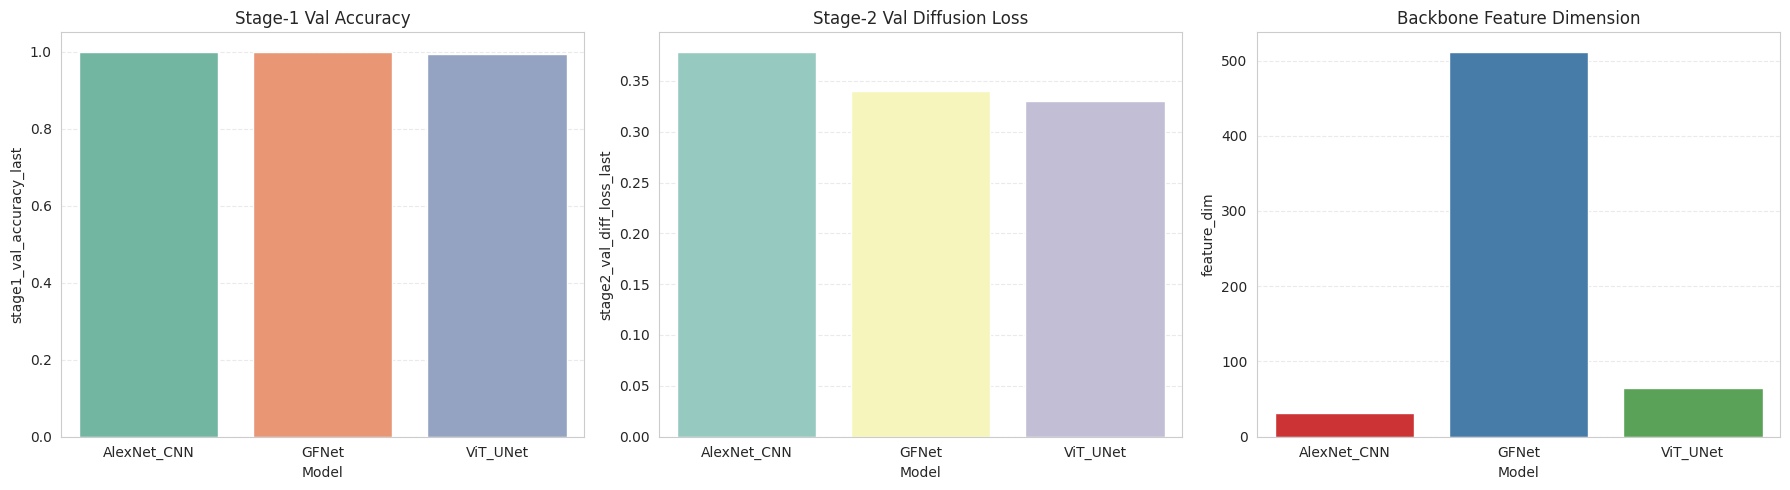

Validation checks passed.


In [ ]:
# -----------------------------
# Reporting and validation
# -----------------------------
summary_df = pd.DataFrame([a['summary'] for a in all_artifacts]).sort_values('stage1_val_accuracy_last', ascending=False)
summary_csv = DAPM_DIR / 'dapm_full_training_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(summary_df)
print('Saved summary:', summary_csv)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=summary_df, x='model_key', y='stage1_val_accuracy_last', ax=axes[0], palette='Set2')
axes[0].set_title('Stage-1 Val Accuracy')
axes[0].set_ylim(0, 1.05)
sns.barplot(data=summary_df, x='model_key', y='stage2_val_diff_loss_last', ax=axes[1], palette='Set3')
axes[1].set_title('Stage-2 Val Diffusion Loss')
sns.barplot(data=summary_df, x='model_key', y='feature_dim', ax=axes[2], palette='Set1')
axes[2].set_title('Backbone Feature Dimension')
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlabel('Model')
fig.tight_layout()
plt.show()

expected_suffixes = [
    '_dapm_full_config.json',
    '_dapm_full_encoder.weights.h5',
    '_dapm_full_source_decoder.weights.h5',
    '_dapm_full_target_decoder.weights.h5',
    '_dapm_full_classifier.weights.h5',
    '_dapm_full_discriminator.weights.h5',
    '_dapm_full_diffusion.weights.h5',
]
for mk in MODEL_KEYS:
    for suf in expected_suffixes:
        path = DAPM_DIR / f'{mk}{suf}'
        assert path.exists(), f'Missing artifact: {path}'
assert summary_csv.exists(), f'Missing summary csv: {summary_csv}'
assert summary_df.shape[0] == 3, f'Expected 3 summary rows, got {summary_df.shape[0]}'
for mk, dim in feature_dims.items():
    assert np.isfinite(dim), f'Non-finite feature dim for {mk}'
    assert int(dim) > 0, f'Invalid feature dim for {mk}: {dim}'
print('Validation checks passed.')



In [10]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, f1_score,
    ConfusionMatrixDisplay
)

def predict_with_dapm_classifier(feature_extractor, encoder, classifier, x_data, batch_size=256):
    """Encoder → classifier path (no diffusion)."""
    ds = tf.data.Dataset.from_tensor_slices(x_data.astype(np.float32)).batch(batch_size)
    all_probs = []
    for xb in ds:
        feat = feature_extractor(xb, training=False)
        z_mu, _, _ = encoder(feat, training=False)
        probs = classifier(z_mu, training=False)
        all_probs.append(probs.numpy())
    all_probs = np.concatenate(all_probs, axis=0)
    return np.argmax(all_probs, axis=-1), all_probs

print("Inference utility ready.")


Inference utility ready.


In [11]:
test_results = {}

for mk in MODEL_KEYS:
    print(f"\n{'='*20} {mk} {'='*20}")

    fe = feature_extractors[mk]
    cfg_path = DAPM_DIR / f'{mk}_dapm_full_config.json'
    with open(cfg_path, 'r') as f:
        cfg = json.load(f)

    fdim = cfg['feature_dim']

    # Rebuild architectures (lightweight, no training)
    enc = build_dapm_encoder(fdim, LATENT_DIM, DECODER_HIDDEN_DIM)
    clf = build_dapm_classifier(LATENT_DIM, num_classes, CLASSIFIER_HIDDEN_DIM)

    # Load saved weights
    enc.load_weights(cfg['weights']['encoder'])
    clf.load_weights(cfg['weights']['classifier'])

    # Predict on test set
    preds, probs = predict_with_dapm_classifier(fe, enc, clf, x_test)

    acc   = accuracy_score(y_test, preds)
    kappa = cohen_kappa_score(y_test, preds)
    wf1   = f1_score(y_test, preds, average='weighted')
    cm    = confusion_matrix(y_test, preds)
    cr    = classification_report(y_test, preds, digits=4)
    aa    = np.mean(cm.diagonal() / cm.sum(axis=1).clip(min=1))

    test_results[mk] = {
        'preds': preds, 'probs': probs,
        'cm': cm, 'cr': cr,
        'acc': acc, 'aa': aa, 'kappa': kappa, 'f1': wf1,
    }

    print(f"OA={acc:.4f}  AA={aa:.4f}  κ={kappa:.4f}  wF1={wf1:.4f}")
    print(cr)



==================== AlexNet_CNN ====================
OA=1.0000  AA=1.0000  κ=1.0000  wF1=1.0000
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1828
           1     1.0000    1.0000    1.0000       908
           2     1.0000    1.0000    1.0000       715
           3     1.0000    1.0000    1.0000       313
           4     1.0000    1.0000    1.0000       207
           5     1.0000    1.0000    1.0000       203
           6     1.0000    1.0000    1.0000       136

    accuracy                         1.0000      4310
   macro avg     1.0000    1.0000    1.0000      4310
weighted avg     1.0000    1.0000    1.0000      4310


==================== GFNet ====================
OA=0.9977  AA=0.9971  κ=0.9969  wF1=0.9977
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997      1828
           1     0.9989    0.9978    0.9983       908
           2     0.9916    0.9944    0.9930       

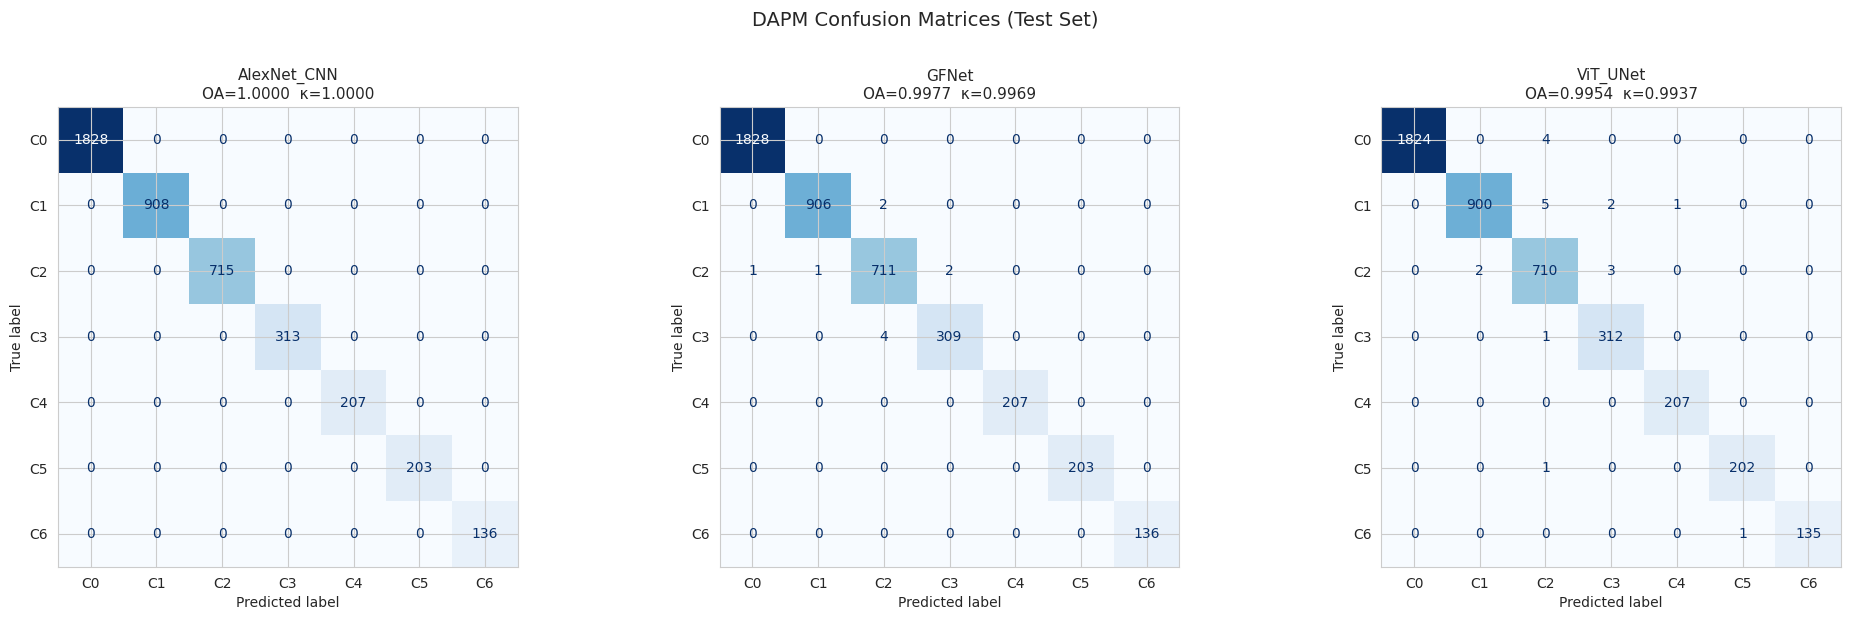

In [12]:
class_names = [f'C{i}' for i in range(num_classes)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, mk in zip(axes, MODEL_KEYS):
    res = test_results[mk]
    ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=class_names
    ).plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'{mk}\nOA={res["acc"]:.4f}  κ={res["kappa"]:.4f}', fontsize=11)

fig.suptitle('DAPM Confusion Matrices (Test Set)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(DAPM_DIR / 'confusion_matrices_raw.png', dpi=150, bbox_inches='tight')
plt.show()


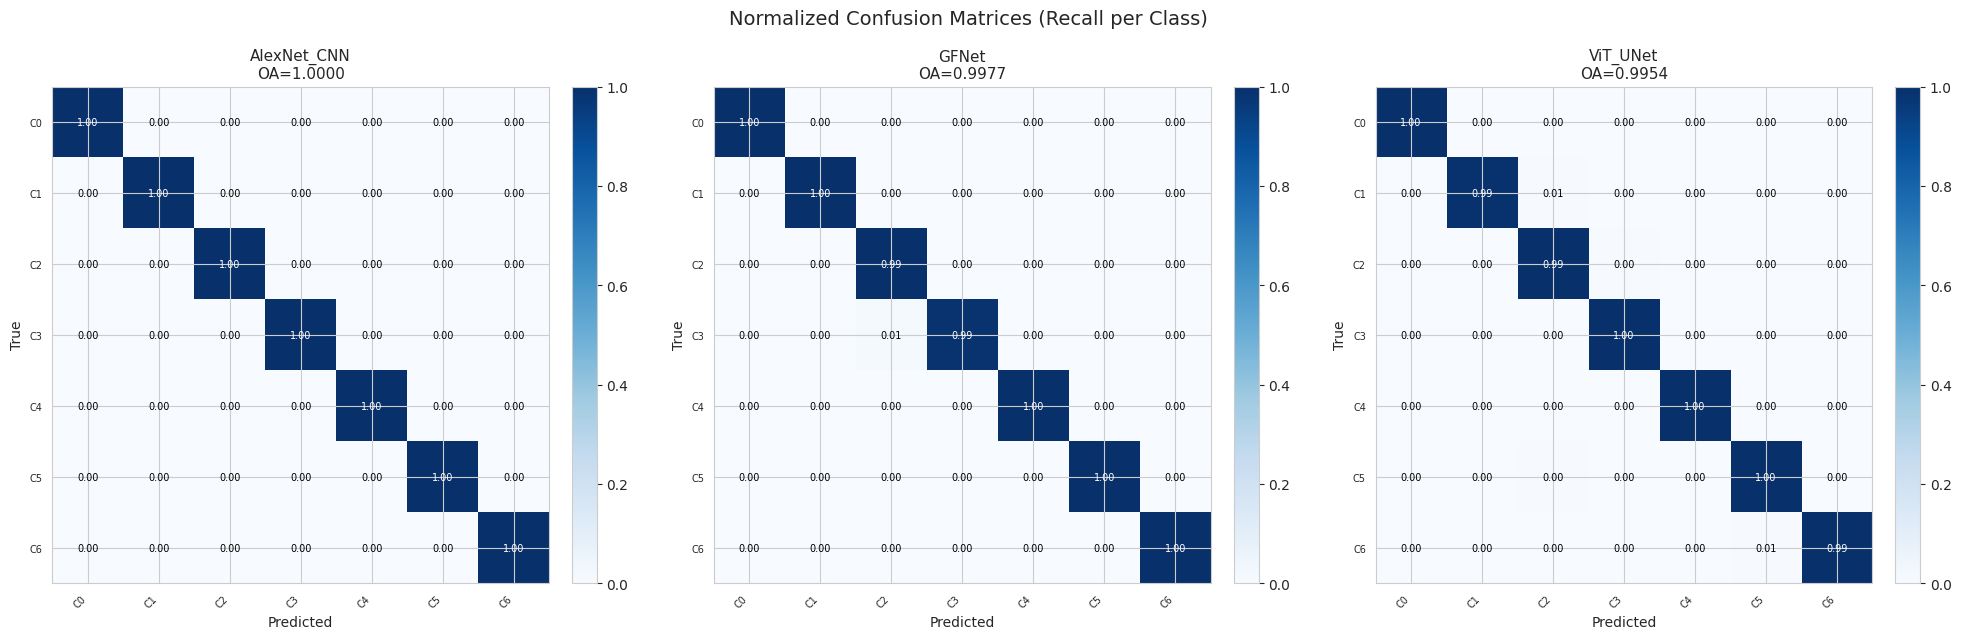

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, mk in zip(axes, MODEL_KEYS):
    cm = test_results[mk]['cm']
    cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(class_names, fontsize=7)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{mk}\nOA={test_results[mk]["acc"]:.4f}', fontsize=11)

    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, f'{cm_norm[i, j]:.2f}',
                    ha='center', va='center',
                    color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=7)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Normalized Confusion Matrices (Recall per Class)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(DAPM_DIR / 'confusion_matrices_normalized.png', dpi=150, bbox_inches='tight')
plt.show()


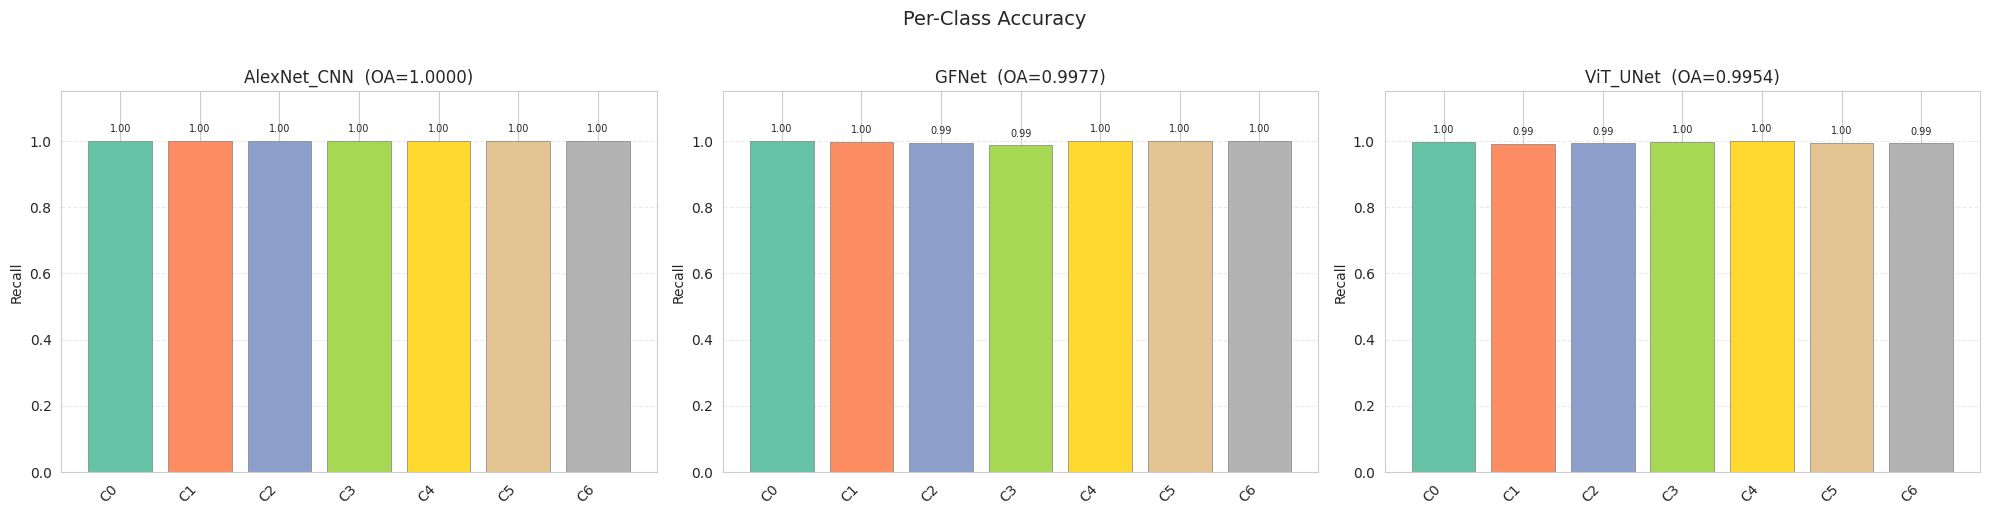

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, mk in zip(axes, MODEL_KEYS):
    cm = test_results[mk]['cm']
    per_class = cm.diagonal() / cm.sum(axis=1).clip(min=1)

    colors = plt.cm.Set2(np.linspace(0, 1, num_classes))
    bars = ax.bar(range(num_classes), per_class, color=colors, edgecolor='gray', linewidth=0.5)

    for bar, v in zip(bars, per_class):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7)

    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Recall')
    ax.set_title(f'{mk}  (OA={test_results[mk]["acc"]:.4f})')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Per-Class Accuracy', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(DAPM_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


      Model      OA       AA    Kappa  Weighted-F1
AlexNet_CNN 1.00000 1.000000 1.000000     1.000000
      GFNet 0.99768 0.997060 0.996853     0.997679
   ViT_UNet 0.99536 0.995219 0.993711     0.995367


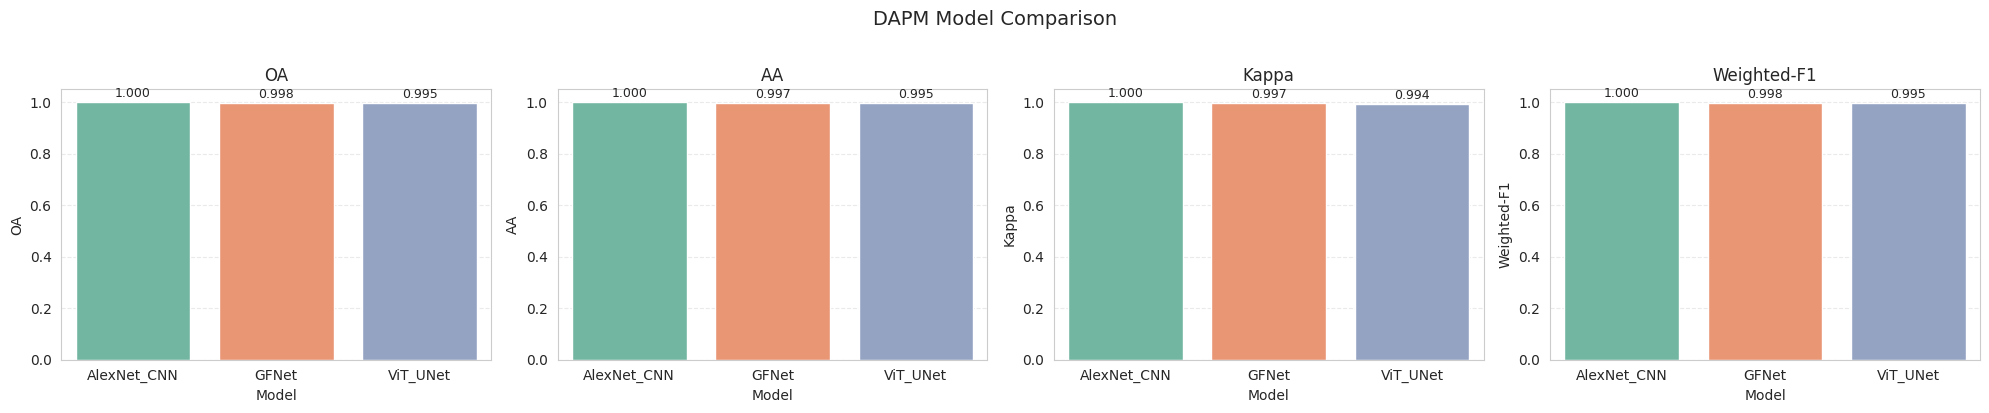

In [15]:
rows = []
for mk in MODEL_KEYS:
    r = test_results[mk]
    rows.append({'Model': mk, 'OA': r['acc'], 'AA': r['aa'],
                 'Kappa': r['kappa'], 'Weighted-F1': r['f1']})

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric in zip(axes, ['OA', 'AA', 'Kappa', 'Weighted-F1']):
    sns.barplot(data=comp_df, x='Model', y=metric, ax=ax, palette='Set2')
    ax.set_ylim(0, 1.05)
    ax.set_title(metric)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.02,
                f'{p.get_height():.3f}', ha='center', fontsize=9)
fig.suptitle('DAPM Model Comparison', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(DAPM_DIR / 'model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()


Predicting full image for AlexNet_CNN ...
  row 0/330
  row 50/330
  row 100/330
  row 150/330
  row 200/330
  row 250/330
  row 300/330
  AlexNet_CNN done.
Predicting full image for GFNet ...
  row 0/330
  row 50/330
  row 100/330
  row 150/330
  row 200/330
  row 250/330
  row 300/330
  GFNet done.
Predicting full image for ViT_UNet ...
  row 0/330
  row 50/330
  row 100/330
  row 150/330
  row 200/330
  row 250/330
  row 300/330
  ViT_UNet done.


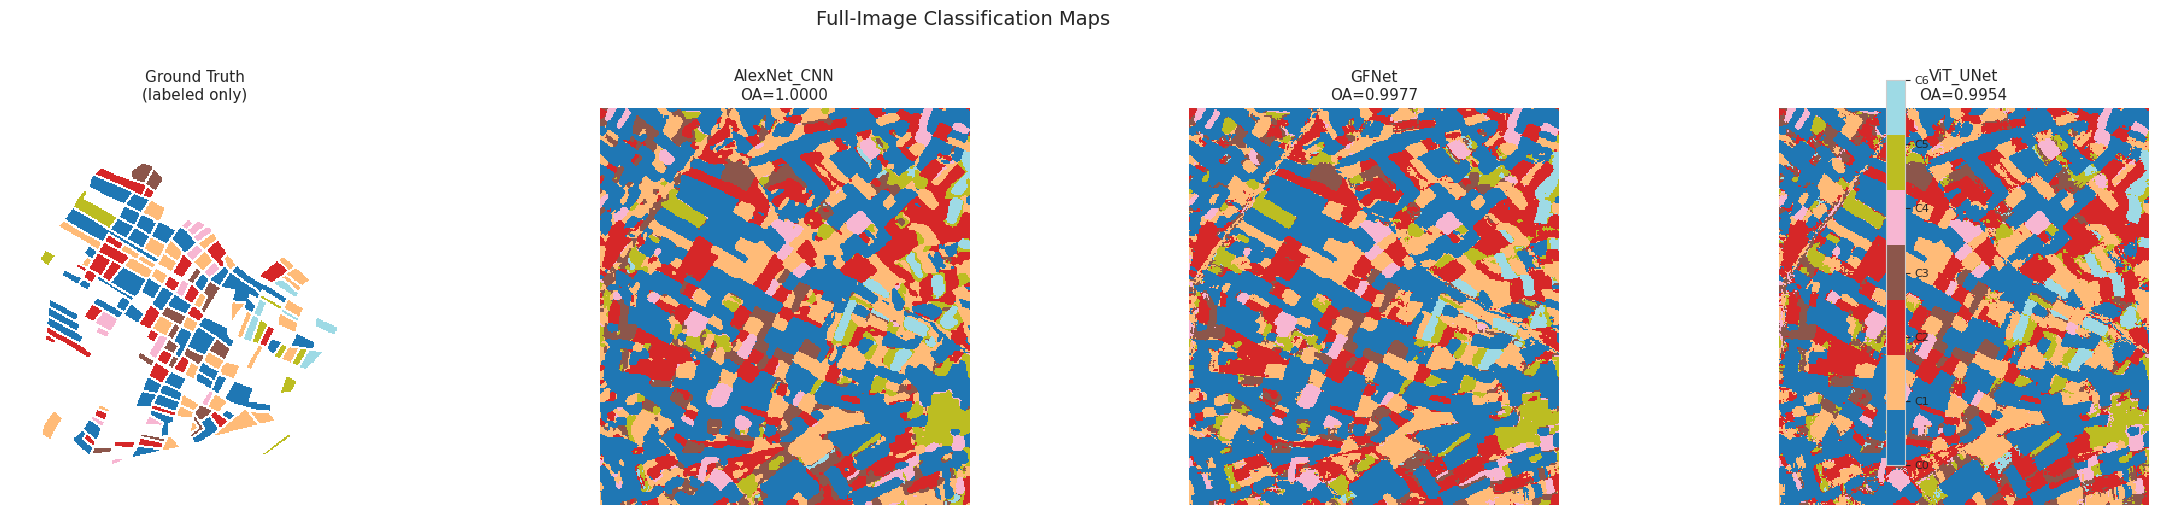

All visualizations saved to: /content/drive/My Drive/m_p/saved_models/dapm_full_artifacts


In [16]:
# Predict every pixel in the image
cmap_classes = plt.cm.get_cmap('tab20', num_classes)

full_maps = {}
for mk in MODEL_KEYS:
    print(f"Predicting full image for {mk} ...")
    fe = feature_extractors[mk]
    cfg = json.load(open(DAPM_DIR / f'{mk}_dapm_full_config.json'))

    enc = build_dapm_encoder(cfg['feature_dim'], LATENT_DIM, DECODER_HIDDEN_DIM)
    clf = build_dapm_classifier(LATENT_DIM, num_classes, CLASSIFIER_HIDDEN_DIM)
    enc.load_weights(cfg['weights']['encoder'])
    clf.load_weights(cfg['weights']['classifier'])

    pad = PATCH_SIZE // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    pred_map = np.full((H, W), -1, dtype=np.int32)

    # Process row by row for manageable batches
    for r in range(H):
        patches = np.stack([
            x_pad[r:r + PATCH_SIZE, c:c + PATCH_SIZE, :]
            for c in range(W)
        ], axis=0)
        feat = fe(patches, training=False)
        z_mu, _, _ = enc(feat, training=False)
        probs = clf(z_mu, training=False)
        pred_map[r, :] = tf.argmax(probs, axis=-1).numpy()
        if r % 50 == 0:
            print(f"  row {r}/{H}")

    full_maps[mk] = pred_map
    print(f"  {mk} done.")

# Ground truth map (0-based; unlabeled → -1)
gt_map = y_img.copy() - 1

# Plot
fig, axes = plt.subplots(1, len(MODEL_KEYS) + 1, figsize=(6 * (len(MODEL_KEYS) + 1), 5))

def show_map(ax, cmap_data, title):
    masked = np.ma.masked_where(cmap_data < 0, cmap_data)
    im = ax.imshow(masked, cmap=cmap_classes, vmin=0, vmax=num_classes - 1, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    return im

show_map(axes[0], gt_map, 'Ground Truth\n(labeled only)')
for i, mk in enumerate(MODEL_KEYS):
    im = show_map(axes[i + 1], full_maps[mk], f'{mk}\nOA={test_results[mk]["acc"]:.4f}')

cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.02,
                     ticks=range(num_classes))
cbar.ax.set_yticklabels([f'C{i}' for i in range(num_classes)], fontsize=8)

fig.suptitle('Full-Image Classification Maps', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(DAPM_DIR / 'full_image_classification_maps.png', dpi=200, bbox_inches='tight')
plt.show()

print("All visualizations saved to:", DAPM_DIR)
